# Trabajo práctico integrador - Grupo 4

El comitente posee un sistema desarrollado sobre una web, con un carrusel que muestra a los usuarios juegos que pueden interesarle al cliente. Actualmente, los juegos mostrados al cliente se eligen de manera aleatoria.
<br><br>
Este es el proceso de minería de datos para obtener el sistema recomendador que reemplazara las recomendaciones aleatorias que actualmente tiene el sistema. Para la realización del proceso, utilizaremos la metodología CRISP-DM. Seguiremos sus fases y actividades genéricas siempre que consideremos que sean requeridas, y en caso de saltear alguna justificaremos por qué no la incluimos.

## Fase 1 - Entendimiento del negocio

Nuestro objetivo en esta fase es entender el problema de negocio y traducirlo a un problema de minería de datos.

### Actividad 1.1: Determinar objetivos de negocio

El objetivo de negocio es aumentar las ganancias por ventas de videojuegos en un 10% para el año 2026 (comparandolo con las ventas del 2025).

### Actividad 1.2: Evaluar la situacion actual

El caso a tratar es sobre una plataforma virtual de venta de videojuegos. Contamos con la siguiente información del sistema:
* Hay un total de 100 juegos en venta.
* El sistema actual de recomendación muestra artículos aleatorios.
* No se cuenta con una base de datos (no hay usuarios, ni preferencias, ni ítems).
<br><br>

Y como supuestos del problema:
* No se agregarán nuevos ítems al carrusel.
* Cada usuario suele comprar entre 7 y 8 con una varianza de 10 juegos.

### Actividad: 1.3 Determinar los objetivos de la minería de datos

El objetivo de la minería de datos es crear un sistema recomendador capaz de recomendar k videojuegos a un usuario determinado, de tal forma que las recomendaciones cumplan con los siguientes requisitos:
* Novedad: El sistema recomendador no debe recomendar videojuegos ya puntuados por el usuario.
* Diversidad: La diversidad de las recomendaciones generadas por el sistema recomendador no deberá ser inferior en más de un 20% a la diversidad obtenida mediante un sistema de recomendaciones aleatorias.
* Serendipia: Al menos un 15% de los artículos recomendados deben ser inesperados para el usuario.
* Relevancia: Al menos un 60% de los artículos recomendados deberán ser relevantes para el usuario.

### Actividad: 1.4: Elaborar un plan de proyecto

Hasta ahora planteamos los objetivos de negocio (lo que quieren los stakeholders), analizamos la situación actual y determinamos qué queremos lograr en el proceso de minería de datos. A partir de ahora, el plan es el siguiente:
1. **Entender los datos:** Coincide con la fase 2 de CRISP-DM. Buscamos:
    * Familiarizarnos con el dataset.
    * Analizar cada atributo (tipo, semántica, rango).
    * Detectar anomalías
    * Verificar la calidad de los datos.
2. **Preparar los datos para el modelo:** Coincide con la fase 3 de CRISP-DM. Buscamos:
    * Asegurar la calidad de los datos.
    * Preparar esos datos para el modelado.
3. **Modelar el sistema recomendador:** Coincide con la fase 4 de CRISP-DM. Buscamos:
    * Seleccionar la técnica de modelado adecuada basándonos en la información obtenida en todo el proceso anterior.
    * Definir métricas de evaluación de los sistemas recomendadores candidatos.
    * Construir los sistemas recomendadores.
    * Evaluarlos según los criterios definidos anteriormente.
    * Elegir el sistema recomendador que más se ajuste a esos criterios.
4. **Evaluar el modelo:** Coincide con la fase 5 de CRISP-DM. Tenemos que verificar que el sistema recomendador elegido cumpla con los objetivos de la minería de datos planteados en la fase 1.
5. **Desplegar el modelo:** Coincide con la fase 6 de CRISP-DM. Consiste en definir cómo implementaremos el sistema recomendador y definir un plan de seguimiento del mismo.
<br>
<br>

Cabe aclarar que en todo momento tendremos en cuenta que CRISP-DM es una metodología iterativa, y por ende contempla (y casi que exige) que no se siga una secuencia lineal entre fases. A lo largo del proceso volveremos hacia atrás entre fases y actividades siempre que lo consideremos necesario. El plan solo representa una secuencia ideal de trabajo, que puede ser ajustada o modificada durante el desarrollo del proyecto.

## Fase 2 - Entendimiento de los datos

El objetivo principal de esta fase es familiarizarnos con los datos. Antes de empezar con este proceso, es necesario cargar todas las librerías que utilizaremos a lo largo del trabajo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns
import statistics

ModuleNotFoundError: No module named 'matplotlib'

### Actividad 2.1: Recolección inicial de los de datos

Los datos de los 100 juegos se encuentran en el archivo subido a GitHub database/games.csv, así que procedemos a cargar este archivo en nuestro Jupyter y verificamos si se cargó correctamente

In [3]:
df = pd.read_csv(r"../database/games.csv")
df

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher,platform_list,genre_list
0,1300540639,Outer Wilds: Echoes of the Eye,2021-09-28,NaN,"Open-World Action, Action RPG, Linear Action A...",A strange satellite photo that can’t be explai...,PC,82.0,8,Generally favorable,89,204,Generally favorable,82,"Mobius Digital, LLC",Annapurna Interactive,['PC'],"['Open-World Action', 'Action RPG', 'Linear Ac..."
1,1300473095,Yakuza Kiwami 2,2018-08-28,M,"Open-World Action, FPS, Survival",Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,69,Generally favorable,84,688,Generally favorable,"85,82,88,83",Ryu ga Gotoku Studios,Sega,"['PlayStation 4', 'PC', 'Xbox One', 'Nintendo ...","['Open-World Action', 'FPS', 'Survival']"
2,1300536274,Lost Judgment,2021-09-21,M,"Open-World Action, FPS, Survival","SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,80,Generally favorable,85,416,Generally favorable,"82,80,83,84",Ryu ga Gotoku Studios,Sega,"['PlayStation 5', 'Xbox Series X', 'PlayStatio...","['Open-World Action', 'FPS', 'Survival']"
3,1300069209,Darksiders II,2012-08-14,M,"Open-World Action, Linear Action Adventure, FPS","Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,63,Generally favorable,81,683,Generally favorable,"83,84,81,85",Vigil Games,"THQ,Spike Chunsoft","['Xbox 360', 'PlayStation 3', 'PC', 'Wii U']","['Open-World Action', 'Linear Action Adventure..."
4,1300491974,Reventure,2019-10-08,T,"Open-World Action, Linear Action Adventure, FPS",The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,7,Generally favorable,76,47,Generally favorable,"84,83",Pixelatto,Pixelatto,"['PC', 'Nintendo Switch']","['Open-World Action', 'Linear Action Adventure..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1300145158,Dead Space 3,2013-02-05,M,"Linear Action Adventure, Action RPG, Open-Worl...",Dead Space 3 embodies deep space terror. Playe...,"PlayStation 3,Xbox 360,PC",78.0,68,Generally favorable,64,997,Mixed or average,"76,78,78",Visceral Games,Electronic Arts,"['PlayStation 3', 'Xbox 360', 'PC']","['Linear Action Adventure', 'Action RPG', 'Ope..."
96,1300459505,Little Nightmares,2017-04-28,T,"Linear Action Adventure, Open-World Action, FPS","Immerse yourself in Little Nightmares, a dark ...","PlayStation 4,Xbox One,PC",78.0,52,Generally favorable,80,1217,Generally favorable,"78,83,81",Tarsier Studios,Bandai Namco Games,"['PlayStation 4', 'Xbox One', 'PC']","['Linear Action Adventure', 'Open-World Action..."
97,1300237117,Volume,2015-08-18,T,"Linear Action Adventure, Action RPG, Open-Worl...",Robert Locksley is a petty thief who happens u...,"PC,PlayStation 4,PlayStation Vita",80.0,34,Generally favorable,73,58,Mixed or average,"80,71,86",Mike Bithell,Mike Bithell,"['PC', 'PlayStation 4', 'PlayStation Vita']","['Linear Action Adventure', 'Action RPG', 'Ope..."
98,1300127177,Alan Wake's American Nightmare,2012-02-22,T,"Linear Action Adventure, Action RPG, Open-Worl...","After the events of Alan Wake, our eponymous h...","Xbox 360,PC",76.0,72,Generally favorable,74,295,Mixed or average,"76,73",Remedy Entertainment,Microsoft Game Studios,"['Xbox 360', 'PC']","['Linear Action Adventure', 'Action RPG', 'Ope..."


Estos datos fueron proporcionados por el stakeholder, el archivo se subió GitHub y ahora lo cargamos en el Jupyter. Está listo para ser tratado en el proceso de minería de datos.

### Actividad 2.2: Descripción de los datos

Necesitamos realizar una descripción detallada de los datos y de sus particularidades.

#### Instancia 2.2.1: Tamaño del dataset, atributos y valores nulos

Utilizamos .info y .info().sum() para conocer la informacion de las columnas del data frame y corroborar que sí tiene 100 juegos en total.

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   100 non-null    int64  
 1   title                100 non-null    object 
 2   releaseDate          100 non-null    object 
 3   rating               78 non-null     object 
 4   genres               100 non-null    object 
 5   description          100 non-null    object 
 6   platforms            100 non-null    object 
 7   metascore            100 non-null    float64
 8   metascore_count      100 non-null    int64  
 9   metascore_sentiment  100 non-null    object 
 10  userscore            100 non-null    int64  
 11  userscore_count      100 non-null    int64  
 12  userscore_sentiment  100 non-null    object 
 13  platform_metascores  100 non-null    object 
 14  developer            100 non-null    object 
 15  publisher            100 non-null    obje

id                      0
title                   0
releaseDate             0
rating                 22
genres                  0
description             0
platforms               0
metascore               0
metascore_count         0
metascore_sentiment     0
userscore               0
userscore_count         0
userscore_sentiment     0
platform_metascores     0
developer               0
publisher               0
platform_list           0
genre_list              0
dtype: int64

Efectivamente, el dataset contiene 100 elementos. Además, podemos ver que en rating se encuentran 22 datos nulos en la columna "rating", mientras que el resto de columnas no tienen valores nulos. Dejamos pendiente el análisis de estos valores nulos para la actividad 2.4 (verificación de la calidad de los datos).
<br>

Tambien logramos conocer cada uno de los atributos del dataset: <br>
* id
* title
* releaseDate
* rating
* genres
* description
* platforms
* metascore
* metascore_count
* metascore_sentiment
* userscore
* userscore_count
* userscore_sentiment
* platform_metascores
* developer
* publisher
* platform_list
* genre_list

#### Instancia 2.2.2: Análisis del atributo "rating"

Ahora, queremos describir c/atributo y entenderlo. Queremos conocer:
* Su tipo
* Su rango de valores
* Su semántica asociada
* Tener una idea de su distribución estadística

Y ya que estabamos hablando del atributo "rating", empezaremos con este.

In [ ]:
print(df["rating"].dtype)
df["rating"].value_counts()

str


rating
M       49
T       26
E10+     2
E        1
Name: count, dtype: int64

Los valores posibles son:
* M
* T
* E10+
* E

Inicialmente pensabamos que estaba relacionado a la puntuación del juego, pero no tiene mucho sentido con los valores vistos. Investigando qué significan estas letras, encontramos que corresponden al sistema de clasificación por edades de ESRB. Estas clasificaciones se muestran en la página oficial de ESRB: [Guía oficial de clasificaciones ESRB](https://www.esrb.org/ratings-guide/)
<br>
<br>

Significado de c/valor (semántica):
* M (Mature) → 17+ años. Contenido para adultos, puede contener violencia fuerte, lenguaje fuerte, etc.
* T (Teen) → 13+ años. Contenido para adolescentes o adultos, puede haber violencia moderada, lenguaje leve o temas sugestivos.
* E10+ (Everyone 10+) → 10+ años. Algo más de acción o violencia caricaturesca.
* E (Everyone) → Apto para todo público.
<br>
<br>

Este atributo es de tipo ordinal. Sus valores representan categorías de clasificación etaria de los videojuegos. Las categorías no son cuantitativas, pero poseen un orden natural según la edad del usuario. Se trata de categorías, como un atributo nominal, pero al tener un orden, es un atributo ordinal. Además, como solo puede tener un solo valor, es univaluado.
<br>
<br>

Al ser un atributo ordinal, el dominio de "rating" serían las categorías de ESRB ya mencionadas, que ordenados de menor a mayor serían:
1. E
2. E10+
3. T
4. M

En consecuencia, el rango ordinal del atributo va desde E (menor restricción) hasta M (mayor restricción).
<br>
<br>

En cuánto a la distribución estadística, podemos ver que la mayoría de juegos son para adultos, otra porción considerable son para adolescentes, y casi ninguno de ellos son para mayores de 10 o para todo público. No consideramos necesario utilizar descriptores básicos, son pocas categorías y su distribución estadística es observable simplemente con la cantidad de datos por categoría.

**Conclusiones del atributo "rating":**
* Tipo: Ordinal univaluado.
* Semántica: Clasificación etaria del juego formato ESRB, E: Todo público, E10+: Mayores de 10, T: Adolescentes mayores de 13, M: Mayores de 17
* Dominio (ordenado): [E, E10+, T, M].
* Distribución estadística: La mayoría son juegos para adultos o adolescentes.

#### Instancia 2.2.3: Análisis del atributo "releaseDate"

Traduciendolo al español, sabemos que la semántica de este atributo es la fecha de lanzamiento del juego (salvo que durante su descripción descubramos algo diferente a esto, mantendremos ésta interpretación). Veamos algunos valores y observemos cómo está codificado el atributo.

In [ ]:
df["releaseDate"].dtype
df["releaseDate"].head(5)

0    2021-09-28
1    2018-08-28
2    2021-09-21
3    2012-08-14
4    2019-10-08
Name: releaseDate, dtype: str

Las fechas están en formato string, pero el tipo de atributo es numérico intervalado-discreto. Es numérico porque es un atributo cuantitativo, es discreto porque entre dos valores no siempre hay un valor (por ejemplo, dos fechas correspondientes a días consecutivos), y es intervalado porque los valores están en una escala ordenada donde las diferencias entre valores tienen significado (podemos calcular cuántos días hay entre dos fechas). Además, es univaluado, pues solo puede tomar un solo valor.
<br>
<br>

Para conocer el rango, pasaremos las fechas codificadas como string a formato date, verificamos que no se haya perdido ninguna fecha por el camino y miramos los máximos y mínimos

In [ ]:
df_datesfixed = df.copy()
df_datesfixed["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
print(len(df_datesfixed))
df_datesfixed["releaseDate"].agg(["min","max"])

100


min   1999-06-17
max   2025-11-11
Name: releaseDate, dtype: datetime64[us]

El rango de fechas entonces es [1996-06-17, 2025-11-11].<br>
<br>
Para darnos una idea de la distribución estadística, utilizaremos descriptores estadísticos. Para ello, nos conviene discretizar las fechas en años, y ahí calculamos la moda, la mediana y el promedio:

In [ ]:
df_dates_as_year = df_datesfixed.copy()
df_dates_as_year["releaseDate"] = pd.to_datetime(df_datesfixed["releaseDate"], errors="coerce").dt.year

# Verifico que el cambio se haya hecho correctamente
print(len(df_dates_as_year))
print("Min:", df_dates_as_year["releaseDate"].min())
print("Max:", df_dates_as_year["releaseDate"].max())

# Calculo el promedio, mediana y moda
promedio = df_dates_as_year["releaseDate"].mean()
mediana = df_dates_as_year["releaseDate"].median()
moda = df_dates_as_year["releaseDate"].mode()[0]
cantidad = df_dates_as_year["releaseDate"].value_counts().iloc[0]

print(f"Promedio: {promedio}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}, cantidad de juegos en ese año: {cantidad}")

100
Min: 1999
Max: 2025
Promedio: 2015.56
Mediana: 2017.0
Moda: 2024, cantidad de juegos en ese año: 12


La distribución parece bastante equilibrada dentro del rango analizado. Sí, está sesgada hacia la izquierda, pero menos de lo que se esperaba. Se podía esperar que, como en los últimos años se han lanzado más juegos que nunca, el promedio, la mediana y la moda iban a estar más sesgados hacia la derecha, y no es el caso. Aún así, como Promedio (2015.56) < Mediana (2017.0) < Moda (2024), podemos afirmar que tiene un sesgo negativo (hacia la izquierda). Otra observación es que podíamos pensar que el juego del 1996 era una "anomalía", pero en cierto modo, que el sesgo hacia los últimos años no sea excesivo, nos discipa de dudas (por el momento, veremos más adelante).

**Conclusiones del atributo "releaseDate":**
* Tipo: Numérico intervalado-discreto univaluado.
* Semántica: Fecha de lanzamiento del juego.
* Rango: [1996-06-17, 2025-11-11].
* Distribución estadística: Sesgo hacia la izquierda (sesgo negativo).

#### Instancia 2.2.4: Semántica y tipo de los atributos "metascore", "metascore_count", "metascore_sentiment", "userscore", "userscore_count", "userscore_sentiment"
Todos estos atributos son similares y están relacionados entre sí. Enseguida veremos porque. Veamos los valores que contienen estos atributos.

In [ ]:
df[["metascore","metascore_count","metascore_sentiment","userscore", "userscore_count","userscore_sentiment"]].tail(10)

,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment
90,79.0,29,Generally favorable,74,119,Mixed or average
91,85.0,46,Generally favorable,81,201,Generally favorable
92,83.0,55,Generally favorable,85,202,Generally favorable
93,89.0,115,Generally favorable,80,5615,Generally favorable
94,90.0,86,Universal acclaim,83,941,Generally favorable
95,78.0,68,Generally favorable,64,997,Mixed or average
96,78.0,52,Generally favorable,80,1217,Generally favorable
97,80.0,34,Generally favorable,73,58,Mixed or average
98,76.0,72,Generally favorable,74,295,Mixed or average
99,77.0,8,Generally favorable,74,28,Mixed or average


Semánticamente, "metascore" es el puntaje promedio que los críticos asignaron al juego en cuestión, "metascore_count" es la cantidad de puntajes tomados para calcular ese promedio, y "metascore_sentiment" es la traducción cualitativa del puntaje numérico que vimos de los criticos, básicamente agrupa los puntajes en rangos y los etiqueta. El rango específico para cada valor de "metascore_sentiment" lo veremos en la actividad 2.3 (exploración de los datos), cuando comparemos "metascore" con "metascore_sentiment".
<br>
<br>

Paralelamente, sucede lo mismo con "userscore", "userscore_count" y "userscore_sentiment". "userscore" se refiere al puntaje promedio de los usuarios, "userscore_count" es la cantidad de puntajes tomados para calcular ese promedio, y "userscore_sentiment" es un adjetivo descriptivo de ese puntaje. Analizaremos que rango abarca cada sentimiento en la actividad 2.3 (exploración de los datos).
<br>
<br>

Tanto "metascore" como "metascore_count", "userscore" y "userscore_count" son atributos numéricos, pues contienen números que representan cantidades. Son numéricos discretos pues los valores son siempre enteros, y son proporcionados porque no pueden tomar valores negativos. Todos ellos son univaluados, pues solo pueden tomar un valor.
<br>
<br>

Por otro lado, "userscore_sentiment" y "metascore_sentiment" son atributos ordinales, pues son categorías que tienen un orden jerárquico pero no podemos establecer una distancia cuantitativa entre características. Numéricamente si podríamos calcularla porque tenemos el "metascore" o el "userscore", pero si tendríamos solo el sentimiento, verdaderamente no sabemos cuánta diferencia hay entre "Generally favorable" y "Mixed or average". Por eso es ordinal. A su vez es univaluado, solo puede tener un valor a la vez.

#### Instancia 2.2.5: Rango y distribución estadística de los atributos "userscore_sentiment" y "metascore_sentiment"

Ya conociendo la semántica de los 6 atributos anteriores, tenemos que ver los rangos/dominios de c/uno. Empecemos con los rangos de "userscore_sentiment" y "metascore_sentiment"

In [ ]:
sentimientos_metascore = df["metascore_sentiment"].unique().tolist()
sentimientos_userscore = df["userscore_sentiment"].unique().tolist()

print("Valores posibles en metascore_sentiment:")
for sentimiento in sentimientos_metascore:
    print(f"• {sentimiento}")

print("\nValores posibles en userscore_sentiment:")
for sentimiento in sentimientos_userscore:
    print(f"• {sentimiento}")

Valores posibles en metascore_sentiment:
• Generally favorable
• Universal acclaim

Valores posibles en userscore_sentiment:
• Generally favorable
• Mixed or average
• Generally unfavorable


El dominio de "metascore_sentiment", ordenado de mayor a menor, sería:
* Generally favorable.
* Universal acclaim.
<br>
<br>

Mientras que el dominio de "userscore_sentiment", ordenado de mayor a menor, sería:
* Generally favorable.
* Mixed or average.
* Generally unfavorable.
<br>
<br>

Podemos ver ya con el sentimiento de la puntuación, que los usuarios suelen poner puntuaciones más bajas a los juegos que los críticos. Seguramente podremos corroborar esto con los descriptores básicos de "userscore" y "metascore". Pero primero veamos la distribución estadística de estas categorías.

In [ ]:
porcentajes_metascore = df["metascore_sentiment"].value_counts(normalize=True) * 100
print("Porcentaje de aparición en metascore_sentiment")
for sentimiento, porcentaje in porcentajes_metascore.items():
    print(f"• {sentimiento}: {porcentaje:.2f}%")
    
print('')
porcentajes_userscore = df["userscore_sentiment"].value_counts(normalize=True) * 100
print("Porcentaje de aparición en userscore_sentiment")
for sentimiento, porcentaje in porcentajes_userscore.items():
    print(f"• {sentimiento}: {porcentaje:.2f}%")

Porcentaje de aparición en metascore_sentiment
• Generally favorable: 97.00%
• Universal acclaim: 3.00%

Porcentaje de aparición en userscore_sentiment
• Generally favorable: 72.00%
• Mixed or average: 27.00%
• Generally unfavorable: 1.00%


Distribución estadística "userscore_sentiment":
* Generally favorable: 72.00%
* Mixed or average: 27.00%
* Generally unfavorable: 1.00%
<br>
<br>

Distribución estadística "metascore_sentiment":
* Generally favorable: 97.00%
* Universal acclaim: 3.00%
<br>
<br>

Con estas distribuciones podemos ver que "metascore_sentiment" no nos dice prácticamente nada del juego, los críticos parece que les gustan todos los juegos del dataset, y aclaman una pequeñísima porción. Los usuarios parece que tienen puntajes más realistas, o por lo menos más distribuidos, aunque en gran parte siguen percibiendo los juegos positivamente.

**Conclusiones del atributo "metascore_sentiment":**
* Tipo: Ordinal univaluado.
* Semántica: Etiqueta cualitativa que resume el consenso de la crítica especializada sobre la calidad del juego.
* Dominio: [Generally favorable, Universal acclaim]
* Distribución estadística: Casi todos dejan un sentimiento favorable, y muy poquitos son aclamados por la crítica universal.

**Conclusiones del atributo "userscore_sentiment":**
* Tipo: Ordinal univaluado
* Semántica: Etiqueta cualitativa que resume el consenso y la percepción de la comunidad de jugadores sobre el juego.
* Dominio: [Generally favorable, Mixed or average, Generally unfavorable]
* Distribución estadística: 3/4 de los juegos son valorados positivamente por los usuarios, algunos tienen opiniones divididas y solo 1 juego del dataset ha tenido recepción negativa.

#### Instancia 2.2.6: Rango y distribución estadística de los atributos "metascore_count" y "userscore_count"

Repasando un poco su semántica, estos atributos cuentan la cantidad de críticos ("metascore_count") y "usuarios" ("userscore_count") que puntuaron el juego y componen el puntaje general del mismo ("metascore" para "metascore_count" y "userscore" para "userscore_count"). Ambos pueden actuar como un intervalo de confianza, a mayor cantidad de reseñas, más representativo y fiable es el puntaje promedio del juego. También pueden ser buenos indicadores de popularidad, ya que si un juego tiene tantas puntuaciones realizadas, es porque es conocido y muy jugado, independientemente de no tenga puntuación tan alta.
<br>
<br>

Ahora sí, vamos con el rango. Entendiendo la semántica, el dominio de valores serían los números enteros positivos, pero podemos acotar un poco ese rango observando los valores de nuestro dataset.

In [ ]:
min_meta = df["metascore_count"].min()
max_meta = df["metascore_count"].max()

min_user = df["userscore_count"].min()
max_user = df["userscore_count"].max()

print("Atributo metascore_count")
print("Mínimo:", min_meta)
print("Máximo:", max_meta)

print('')
print("Atributo userscore_count")
print("Mínimo:", min_user)
print("Máximo:", max_user)

Atributo metascore_count
Mínimo: 6
Máximo: 115

Atributo userscore_count
Mínimo: 9
Máximo: 7334


Rango "metascore_count": [6,115]
<br>
Rango "userscore_count": [9,7334]
<br>

No podemos concluir demasiado a partir de estos rangos, solo podemos empezar a pensar hay muchos más usuarios que puntúan los juegos con respecto a los críticos que los puntúan, lo cuál es totalmente esperable. Confirmaremos esto mediante descriptores estadísticos.

In [ ]:
media = df["metascore_count"].mean()
mediana = df["metascore_count"].median()
desviacion = df["metascore_count"].std()

print("Estadísticas de metascore_count")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

media = df["userscore_count"].mean()
mediana = df["userscore_count"].median()
desviacion = df["userscore_count"].std()

print('')
print("Estadísticas de userscore_count")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

Estadísticas de metascore_count
Media: 43.16
Mediana: 44.00
Desviación Estándar: 25.73

Estadísticas de userscore_count
Media: 896.24
Mediana: 221.00
Desviación Estándar: 1485.15


Descriptores estadísticos de "metascore_count":
* Media: 43.16
* Mediana: 44
* Desviacion Estandar: 25.73
<br>
<br>

Descriptores estadísticos de "userscore_count":
* Media: 896.24
* Mediana: 221.00
* Desviacion Estandar: 1485.15
<br>
<br>

Decidimos no utilizar la moda ya que no tiene mucho sentido teniendo tantos valores discretos posibles. Podríamos discretizar, pero creemos que con la media y la mediana alcanza. La varianza tampoco la incluimos dado a que no es tan interpretable como la desviación estándar.
<br>

Respecto a los valores hallados, se corrobora lo que esperabamos, la mediana y el promedio nos muestran que la mayoría de juegos son puntuados por muchos más usuarios que por críticos. En "metascore_count", la media y mediana son similares y están bastante centradas dentro del rango, lo que indica que la distribución es simétrica. Sabemos que 40 no está en el centro del rango [8, 115], pero sería normal que haya un juego o dos que tengan tantas reseñas de críticos y en realidad la mayoría de juegos esté en [8, 115]. A su vez, la desviación estándar es inusualmente alta (25.73), se observa una dispersión considerable en los datos.

A diferencia de las críticas profesionales, el atributo "userscore_count" muestra una distribución asimétrica. Hay una grandísima diferencia entre la mediana y el promedio. Esto indica que hay algunos juegos con muchísimas reseñas de usuario que están sesgando el promedio y haciendo que parezca más grande, pero la mediana nos muestra que ese promedio no es representativo del dataset. Como Mediana < Promedio, la distribución está sesgada positivamente (hacia la derecha). La desviación estándar también es altísima, confirmandonos que hay un grupo reducido de juegos hiperpoulares que acumulan reseñas y el resto tiene muchas menos.

**Conclusiones del atributo "metascore_count":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Cantidad de reseñas de críticos profesionales usadas para el promedio del puntaje del juego "userscore".
* Rango: [6, 115].
* Distribución estadística: Simétrica con alta dispersión.

**Conclusiones del atributo "userscore_count":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Cantidad de reseñas de usuarios utilizadas para el promedio del puntaje del juego "userscore".
* Rango: [9, 7334].
* Distribución estadística: Sesgo hacia la derecha (positivo) con alta dispersión.

#### Instancia 2.2.7: Rango y distribución estadística de los atributos "userscore" y "metascore"

In [ ]:
min_meta = df["metascore"].min()
max_meta = df["metascore"].max()

min_user = df["userscore"].min()
max_user = df["userscore"].max()

print("Atributo metascore")
print("Mínimo:", min_meta)
print("Máximo:", max_meta)

print('')
print("Atributo userscore")
print("Mínimo:", min_user)
print("Máximo:", max_user)

Atributo metascore
Mínimo: 75.0
Máximo: 91.0

Atributo userscore
Mínimo: 42
Máximo: 89


Rango "metascore": [75,91]
<br>
Rango "userscore": [42,89]
<br>

Confirmamos lo que ya sospechabamos observando las categorías de "userscore_sentiment" y "metascore_sentiment". El rango en el que se mueve "metascore" es mucho más pequeño que el rango de "userscore". Puede ser que los usuarios tiendan a menospreciar juegos que no sean de su agrado, mientras que los críticos se mantienen objetivos y le encuentran lo positivo al juego para terminar dandole un buen puntaje.
<br>
<br>

Continuemos con la distribución estadística:

In [ ]:
media = df["metascore"].mean()
mediana = df["metascore"].median()
desviacion = df["metascore"].std()

print("Estadísticas de metascore")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

media = df["userscore"].mean()
mediana = df["userscore"].median()
desviacion = df["userscore"].std()

print('')
print("Estadísticas de userscore")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

Estadísticas de metascore
Media: 81.47
Mediana: 81.00
Desviación Estándar: 4.33

Estadísticas de userscore
Media: 76.64
Mediana: 78.00
Desviación Estándar: 8.54


Al igual que con "userscore_count" y "metascore_count", no calcularemos la moda ni la varianza. La moda carece de sentido con tantos valores discretos y discretizar sería lo que ya se hizo en los atributos "userscore_sentiment" y "metascore_sentiment". Y la varianza es poco interpretable respecto de la desviación estándar, que es el descriptor que utilizaremos en su lugar.
<br>
<br>

Descriptores estadísticos de "metascore":
* Media: 81.47
* Mediana: 81
* Desviacion Estandar: 4.33
<br>
<br>

Descriptores estadísticos de "userscore":
* Media: 76.64
* Mediana: 78.00
* Desviacion Estandar: 8.54
<br>
<br>

Con los descriptores confirmamos lo que ya se veía en los rangos, los puntajes de los críticos suelen ser un poco más altos que los puntajes de los usuarios. Además, como los puntajes de los críticos tienen menor desviación estándar que los de los usuarios, podemos deducir que los críticos son más consistentes con sus puntajes, mientras que los usuarios presentan opiniones más dispersas. Estadísticamente, si comparamos los valores de desviación estándar con los rangos observados (4.33 con [75,91] y 8.54 con [42,89]), la dispersión es moderada en ambos. Pero si consideramos el rango real en el que se mueven los puntajes [0,100], podemos afirmar que la dispersión en "metascore" es baja, mientras que en "userscore" es moderada tendiendo a baja.
<br>
<br>

La distribución de "metascore" parece bastante simétrica, dado que Media ≈ Mediana, mientras que "userscore" presenta un sesgo hacia la izquierda (negativo), porque Mediana > Promedio.

**Conclusiones del atributo "metascore":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Promedio del puntaje de reseñas de críticos al juego.
* Rango: [75, 91].
* Distribución estadística: Simétrica con baja dispersión

**Conclusiones del atributo "userscore":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Promedio del puntaje de reseñas de usuarios al juego.
* Rango: [42, 89].
* Distribución estadística: Sesgo hacia la izquierda (negativo) con dispersión moderada.

#### Instancia 2.2.8: Análisis de los atributos "genres" y "genres_list"

Primero veamos qué valores contiene el atributo "genres"

In [ ]:
df["genres"].head(10)

0    Open-World Action, Action RPG, Linear Action Adventure
1                          Open-World Action, FPS, Survival
2                          Open-World Action, FPS, Survival
3           Open-World Action, Linear Action Adventure, FPS
4           Open-World Action, Linear Action Adventure, FPS
5    Open-World Action, Action RPG, Linear Action Adventure
6                        Open-World Action, Action RPG, FPS
7    Open-World Action, Action RPG, Linear Action Adventure
8                          Open-World Action, FPS, Survival
9    Open-World Action, Action RPG, Linear Action Adventure
Name: genres, dtype: str

Semánticamente, contiene una lista de los géneros a los que pertenece el juego en cuestión. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.
<br>
<br>

Veamos ahora entonces el dominio de valores posibles de este atributo (o géneros posibles), y de paso cuántos juegos tiene c/género:

In [ ]:
generos_expandidos = df['genres'].str.split(',').explode().str.strip()

conteo_generos = generos_expandidos.value_counts()

for genero, cantidad in conteo_generos.items():
    print(f"{genero}: {cantidad}")

Open-World Action: 89
FPS: 69
Action RPG: 67
Linear Action Adventure: 41
Survival: 34


Entonces, el juego pertenece a uno o más de estos géneros:
* Open-World Action (89)
* FPS (69)
* Action RPG (67)
* Linear Action Adventure (41)
* Survival (34)
<br>
<br>

Otra observación es que todos los juegos que visualizamos en las primeras y últimas filas tienen exactamente 3 géneros asociados, ni más ni menos. Para confirmar si esto es una regla o una casualidad, veamos cuántos géneros tiene c/juego en el dataset

In [ ]:
df["genres"].str.split(",").str.len().value_counts()

genres
3    100
Name: count, dtype: int64

Confirmamos acá que todos los juegos tienen 3 géneros asociados, ni más ni menos. Además, pasándo a la distribución estadística:
* El género Open-World Action aparece en la mayoría de juegos (89).
* Más de la mitad de los juegos incluyen los géneros FPS (69) o Action RPG (67).
* Aproximadamente un tercio de los juegos presentan los géneros Linear Action Adventure (41) o Survival (34).
<br>
<br>

El atributo "genres" y el atributo "genres_list" significan lo mismo. Ambos contienen los géneros a los que pertenece el juego, solo cambia su codificación. Lo podemos verificar en el siguiente código

In [ ]:
pd.set_option("display.max_colwidth", None)
df[["genre_list", "genres"]].head(10)

,genre_list,genres
0,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"
1,"['Open-World Action', 'FPS', 'Survival']","Open-World Action, FPS, Survival"
2,"['Open-World Action', 'FPS', 'Survival']","Open-World Action, FPS, Survival"
3,"['Open-World Action', 'Linear Action Adventure', 'FPS']","Open-World Action, Linear Action Adventure, FPS"
4,"['Open-World Action', 'Linear Action Adventure', 'FPS']","Open-World Action, Linear Action Adventure, FPS"
5,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"
6,"['Open-World Action', 'Action RPG', 'FPS']","Open-World Action, Action RPG, FPS"
7,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"
8,"['Open-World Action', 'FPS', 'Survival']","Open-World Action, FPS, Survival"
9,"['Open-World Action', 'Action RPG', 'Linear Action Adventure']","Open-World Action, Action RPG, Linear Action Adventure"


Nos encargaremos de tratar esta redundancia en la fase 3 (preparación de los datos).

**Conclusiones del atributo "genres":**
* Tipo: Nominal multivaluado.
* Semántica: Géneros a los que pertenece el juego.
* Dominio: [Open-World Action, FPS, Action RPG, Linear Action Adventure, Survival].
* Distribución estadística: Muchísimos Open-World Action, bastantes FPS y Action RPG, y una cantidad considerable de Linear Action Adventure y Survival. 

#### Instancia 2.2.9: Análisis de los atributos "platforms" y "platform_list"

Algo similar sucede con los atributos "platforms" y "platforms_list"

In [ ]:
df[["platforms", "platform_list"]].head(10)

,platforms,platform_list
0,PC,['PC']
1,"PlayStation 4,PC,Xbox One,Nintendo Switch 2","['PlayStation 4', 'PC', 'Xbox One', 'Nintendo Switch 2']"
2,"PlayStation 5,Xbox Series X,PlayStation 4,PC","['PlayStation 5', 'Xbox Series X', 'PlayStation 4', 'PC']"
3,"Xbox 360,PlayStation 3,PC,Wii U","['Xbox 360', 'PlayStation 3', 'PC', 'Wii U']"
4,"PC,Nintendo Switch","['PC', 'Nintendo Switch']"
5,"PlayStation 4,Xbox One,PC,PlayStation 5,Xbox Series X","['PlayStation 4', 'Xbox One', 'PC', 'PlayStation 5', 'Xbox Series X']"
6,"PlayStation 4,Xbox One,PlayStation 5,Xbox Series X,PC","['PlayStation 4', 'Xbox One', 'PlayStation 5', 'Xbox Series X', 'PC']"
7,"Xbox Series X,PC","['Xbox Series X', 'PC']"
8,PC,['PC']
9,"PC,PlayStation 4","['PC', 'PlayStation 4']"


Ambos atributos contienen las plataformas para las que el juego está disponible (esa es la semántica), solo que "platforms" en formato separado por comas, y "platform_list" como lista. Esta es una redundancia que trataremos en la fase 3 (preparación de los datos).
<br>
<br>

Veamos cuáles son las plataformas disponibles y cuántos juegos tiene cada plataforma

In [ ]:
df["platforms"].str.split(",").explode().value_counts()

platforms
PC                   100
PlayStation 4         31
Xbox One              23
PlayStation 5         23
Nintendo Switch       21
Xbox Series X         19
Xbox 360              15
PlayStation 3          9
PlayStation 2          8
Xbox                   8
Wii U                  5
PSP                    5
Wii                    4
GameCube               4
Nintendo Switch 2      1
DS                     1
iOS (iPhone/iPad)      1
PlayStation Vita       1
Name: count, dtype: int64

Entonces, el juego puede jugarse en una o más de estas plataformas:
* PC
* PlayStation 4
* Xbox One
* PlayStation 5
* Nintendo Switch
* Xbox Series X
* Xbox 360
* PlayStation 3
* PlayStation 2
* Xbox
* Wii U
* PSP
* Wii
* GameCube
* Nintendo Switch 2
* DS
* iOS (iPhone/iPad)
* PlayStation Vita

Este listado de valores posibles es el dominio del atributo. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.
<br>
<br>

Estadísticamente:
* Todos los juegos son de PC
* 1/4 de los juegos aproximadamente son de PlayStation, Nintendo Switch o Xbox.
* Solo una pequeña porción de juegos admiten otras plataformas además de las mencionadas.

**Conclusiones del atributo "platforms":**
* Tipo: Nominal multivaluado.
* Semántica: Plataformas para las que el juego está disponible.
* Dominio: [PC, PlayStation 4, Xbox One, PlayStation 5, Nintendo Switch, Xbox Series X, Xbox 360, PlayStation 3, PlayStation 2, Xbox, Wii U, PSP, Wii, GameCube, Nintendo Switch 2, DS, iOS (iPhone/iPad), PlayStation Vita].
* Distribución estadística: Todos de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas.

#### Instancia 2.2.10: Análisis del atributo "platforms_metascore"

Empecemos por observar los valores que contiene este atributo junto con la columna "platforms"

In [ ]:
df[["platforms", "platform_metascores"]].head(10)

,platforms,platform_metascores
0,PC,82
1,"PlayStation 4,PC,Xbox One,Nintendo Switch 2","85,82,88,83"
2,"PlayStation 5,Xbox Series X,PlayStation 4,PC","82,80,83,84"
3,"Xbox 360,PlayStation 3,PC,Wii U","83,84,81,85"
4,"PC,Nintendo Switch","84,83"
5,"PlayStation 4,Xbox One,PC,PlayStation 5,Xbox Series X","70,76,72,66,74"
6,"PlayStation 4,Xbox One,PlayStation 5,Xbox Series X,PC","80,82,84,84,82"
7,"Xbox Series X,PC","81,80"
8,PC,83
9,"PC,PlayStation 4","75,74"


Por lógica, la semántica de este artículo es que contiene el puntaje que le dan al juego las críticas profesionales de Metacritic en esa plataforma específica. Podemos notar que contiene números enteros con significado cuantitativo, lo que lo hace un atributo numérico. El 0 es absoluto, sería la peor puntuación y no se pueden tomar valores negativos, por lo que es numérico proporcionado, y al ser números enteros, también es numérico discreto. Además, es multivaluado, pues puede tener varios valores para una sola fila.
<br>
<br>

También queremos conocer el rango de puntajes, y para ello vamos a consultar mediante código el máximo y el mínimo de esos valores

In [ ]:
all_scores = []

for s in df["platform_metascores"]:
    nums = list(map(int, s.split(",")))
    all_scores.extend(nums)

print("Máximo metascore de plataformas:", max(all_scores))
print("Mínimo metascore de plataformas:", min(all_scores))

Máximo metascore de plataformas: 93
Mínimo metascore de plataformas: 52


Entonces, el rango del metascore por plataforma es [52,93].

In [ ]:
print("Promedio:", statistics.mean(all_scores))
print("Mediana:", statistics.median(all_scores))
print("Moda:", statistics.mode(all_scores))

Promedio: 79.57347670250896
Mediana: 80
Moda: 83


Claramente es una distribución sesgada negativamente hacia la izquierda, Moda > Mediana > Promedio. Además, los tres descriptores básicos están más cerca de la cota superior del rango que de la cota inferior. Además, esto nos hace pensar que quizás el valor mínimo podría ser una anomalía. Podremos verlo con más claridad en la visualización.

**Conclusiones del atributo "platforms_metascores":**
* Tipo: Numérico intervalado-discreto multivaluado.
* Semántica: Puntaje según Metacritic en c/plataforma específica
* Rango: [52,93].
* Distribución estadística: Sesgada negativamente hacia la izquierda.

#### Instancia 2.2.11: Análisis del atributo "id"

El "id" es un atributo asociado a el identificador del juego en la base de datos, por lo que no tiene sentido su análisis.

#### Instancia 2.2.12: Análisis de los atributos "title" y "description"
Al igual que el identificador, estos atributos no presentan valor al análisis de datos.

#### Instancia 2.2.13: Análisis del atributo "developer"

Comenzamos observando algunos valores del atributo para ver de qué se trata

In [ ]:
df["developer"].head(5)

0      Mobius Digital, LLC
1    Ryu ga Gotoku Studios
2    Ryu ga Gotoku Studios
3              Vigil Games
4                Pixelatto
Name: developer, dtype: str

Semánticamente, este atributo contiene la lista de estudios o empresas desarrolladoras que participaron en la elaboración del juego. Se trata de un atributo nominal, ya que tiene diferentes categorías que serían las diferentes empresas desarrolladoras, y es multivaluado porque varias empresas o estudios pudieron haberlo desarrollado.
<br>
<br>

Ahora, vamos a analizar el dominio de valores posibles junto con su distribución estadística

In [ ]:
desarrolladores = (df["developer"].str.split(",").explode().str.strip().value_counts())

print(f"LISTA DE DESARROLLADORES ({len(desarrolladores)} únicos)")
for dev, count in desarrolladores.items():
    print(f"• {dev}: {count}")

LISTA DE DESARROLLADORES (83 únicos)
• Capcom: 6
• Ubisoft Montreal: 4
• Crystal Dynamics: 3
• Raven Software: 3
• Remedy Entertainment: 3
• Ryu ga Gotoku Studios: 2
• Ubisoft: 2
• Kojima Productions: 2
• Croteam: 2
• Round 8 Studio of NEOWIZ: 2
• PlatinumGames: 2
• Warhorse Studios: 2
• Mobius Digital: 1
• LLC: 1
• Vigil Games: 1
• Pixelatto: 1
• Microbird Games: 1
• Rockstar Games: 1
• Double Eleven: 1
• Ubisoft Reflections: 1
• Shed-Works: 1
• Rockstar Vancouver: 1
• Mad Doc Software: 1
• Virtuos: 1
• Volition Inc.: 1
• Ostrich Banditos: 1
• Awaceb: 1
• Spytihnev: 1
• Digital Extremes: 1
• S2 Games: 1
• Indefatigable: 1
• Gruby Entertainment: 1
• Broadside Games: 1
• Crytek: 1
• LucasArts: 1
• Treyarch: 1
• Bounding Box Software: 1
• id Software: 1
• Dreamworks Games: 1
• Sledgehammer Games: 1
• Outrage Games: 1
• Nightdive Studios: 1
• Catchweight Studio: 1
• Endnight Studios: 1
• Ironwood Studios: 1
• Techland: 1
• 11 bit studios: 1
• John Szymanski: 1
• Capcom R&D Division 1: 1
•

El dominio de desarroladores incluye 83 entidades, lo que indica una alta cardinalidad respecto del total del dataset. La gran mayoría de los estudios aparece una única vez, mientras que unos pocos estudios participan en varios juegos del conjunto de datos, aunque proporcionalmente siguen siendo pocos. La distribución es asimétrica, pocos valores frecuentes y muchos valores poco frecuentes.

**Conclusiones del atributo "developer":**
* Tipo: Nominal multivaluado.
* Semántica: Entidades, estudios o empresas que desarrollaron el videojuego.
* Dominio: Cadenas de texto.
* Distribución estadística: Asimétrica.

#### Instancia 2.2.14: Análisis del atributo "publisher"

Veamos algunos valores del atributo "publisher" para entender su semántica. Añadimos el atributo "developer" ya analizado para hacer un par de observaciones

In [ ]:
df[["publisher","developer"]].head(5)

,publisher,developer
0,Annapurna Interactive,"Mobius Digital, LLC"
1,Sega,Ryu ga Gotoku Studios
2,Sega,Ryu ga Gotoku Studios
3,"THQ,Spike Chunsoft",Vigil Games
4,Pixelatto,Pixelatto


Semánticamente, corresponde a la empresa editora o distribuidora del videojuego. A diferencia del desarrollador, el "publisher" suele encargarse de la financiación, el marketing y la distribución. Observando la muestra inicial, notamos nombres de gran peso en la industria como Sega. También observamos casos como Pixelatto, donde la misma empresa actúa tanto como desarrolladora y como editora. Es un atributo nominal multivaluado, ya que se comporta igual que "developer" (respecto al tipo de atributo)
<br>
<br>

Ahora, vamos a analizar el dominio de valores posibles junto con su distribución estadística

In [ ]:
publishers = (df["publisher"].str.split(",").explode().str.strip().value_counts())

print(f"\nLISTA DE PUBLISHERS ({len(publishers)} únicos)")
for pub, count in publishers.items():
    print(f"• {pub}: {count}")


LISTA DE PUBLISHERS (84 únicos)
• Capcom: 9
• Ubisoft: 8
• Electronic Arts: 7
• Activision: 6
• Sega: 4
• Sony Interactive Entertainment: 4
• Rockstar Games: 3
• Eidos Interactive: 3
• Deep Silver: 3
• Devolver Digital: 3
• Limited Run Games: 3
• Square Enix: 3
• Humble Games: 3
• Microsoft Game Studios: 3
• THQ: 2
• Spike Chunsoft: 2
• Bethesda Softworks: 2
• Koch Media: 2
• Kepler Interactive: 2
• CyberFront: 2
• LucasArts: 2
• Neowiz: 2
• Oculus Studios: 2
• Bandai Namco Games: 2
• Atari SA: 2
• Spike: 2
• SCEE: 2
• Annapurna Interactive: 1
• Pixelatto: 1
• Curve Games: 1
• Curve Digital: 1
• Raw Fury: 1
• Hanbitsoft: 1
• PlayStation Studios: 1
• Konami: 1
• Adult Swim: 1
• Maximum Games: 1
• Gathering of Developers: 1
• Take-Two Interactive: 1
• Spytihnev: 1
• Infogrames: 1
• iGames: 1
• Digital Jesters: 1
• New Blood Interactive: 1
• Crunching Koalas: 1
• Ravenscourt: 1
• EA Games: 1
• Sold Out Software: 1
• Interplay: 1
• Nightdive Studios: 1
• Team17: 1
• Newnight: 1
• Epic Gam

El análisis es muy similar al realizado con "developer". El dominio es de 84 entidades, alta cardinalidad, y la gran mayoría de los estudios solo aparece una vez mientras que unos pocos aparecen varias veces. Si es cierto que hay editoras que se repiten un poquito más que las desarrolladoras en "developer", pero no cambia que la distribución siga siendo asimétrica.

**Conclusiones del atributo "publisher":**
* Tipo: Nominal multivaluado.
* Semántica: Empresa editora y distribuidora del videjouego.
* Dominio: Cadenas de texto.
* Distribución estadística: Asimétrica

#### Instancia 2.2.15: Resumen del análisis de atributos

| | **Tipo** | **Semántica** | **Rango/Dominio** | **Distribucion estadística** |
|----------|------|-----------|---------------|---------------------------|
| **id** | Numérico discreto-proporcionado univaluado | Identificador único del juego | [1300000098,1300707511] | No aplica |
| **title** | Nominal univaluado | Título oficial del videojuego | Cadenas de texto únicas | No aplica |
| **releaseDate** | Numérico discreto-intervalado univaluado | Fecha de lanzamiento del juego | [1996-06-17, 2025-11-11] | Sesgada negativamente |
| **rating** | Ordinal univaluado | Clasificación etaria del juego formato ESRB. E: Todo público, E10+: Mayores de 10, T: Adolescentes mayores de 13, M: Mayores de 17 | [E, E10+, T, M] | La mayoría son juegos para adultos o adolescentes |
| **genres** | Nominal multivaluado | Géneros a los que pertenece el juego | [Open-World Action, FPS, Action RPG, Linear Action Adventure, Survival]| Muchísimos Open-World Action, bastantes FPS y Action RPG, y una cantidad considerable de Survival y Linear Action Adventure |
| **description** | Nominal univaluado | Descripción del videojuego y contexto sobre el mismo | Cadenasde texto entre 65 y 2066 caracteres de longitud | No analizada |
| **platforms** | Nominal multivaluado | Plataformas para las que el juego está disponible | PC, PlayStation 4, Xbox One, PlayStation 5, Nintendo Switch, Xbox Series X, Xbox 360, PlayStation 3, PlayStation 2, Xbox, Wii U, PSP, Wii, GameCube, Nintendo Switch 2, DS, iOS (iPhone/iPad), PlayStation Vita | Todos de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas |
| **metascore** | Numérico discreto-proporcionado univaluado | Promedio del puntaje de reseñas de críticos al juego | [75, 91] | Simétrica con baja dispersión |
| **metascore_count** | Numérico discreto-proporcionado univaluado | Cantidad de reseñas de críticos utilizadas para calcular "userscore" | [6,115] | Simétrica con alta dispersión |
| **metascore_sentiment** | Ordinal univaluado | Etiqueta cualitativa que resume "metascore" | [Generally favorable, Universal acclaim] | Casi todos dejan un sentimiento favorable |
| **userscore** | Numérico discreto-proporcionado univaluado | Promedio del puntaje de reseñas de usuarios al juego | [42, 89] | Sesgada negativamente con dispersión moderada |
| **userscore_count** | Numérico discreto-proporcionado univaluado | Cantidad de reseñas de usuarios utilizadas para calcular "userscore" | [9, 7334] | Sesgada positivamente con alta dispersión |
| **userscore_sentiment** | Ordinal univaluado | Etiqueta cualitativa que resume "userscore" | [Generally favorable, Mixed or average, Generally unfavorable] | 3/4 dejan sentimientos favorables y algunos presentan opiniones divididas |
| **platform_metascores** | Numérico discreto-intervalado multivaluado | Puntaje según Metacritic en c/plataforma específica | [52,93] | Sesgada negativamente |
| **developer** | Nominal multivaluado | Entidades que desarrollaron el videojuego | Cadenas de texto | Asimétrica con alta cardinalidad |
| **publisher** | Nominal multivaluado | Empresa editora y distribuidora del videjouego | Cadenas de texto | Asimétrica con alta cardinalidad |
| **platform_list** | Nominal multivaluado | Plataformas para las que el juego está disponible | PC, PlayStation 4, Xbox One, PlayStation 5, Nintendo Switch, Xbox Series X, Xbox 360, PlayStation 3, PlayStation 2, Xbox, Wii U, PSP, Wii, GameCube, Nintendo Switch 2, DS, iOS (iPhone/iPad), PlayStation Vita | Todos de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas |
| **genre_list** | Nominal multivaluado | Géneros a los que pertenece el juego | [Open-World Action, FPS, Action RPG, Linear Action Adventure, Survival]| Muchísimos Open-World Action, bastantes FPS y Action RPG, y una cantidad considerable de Survival y Linear Action Adventure |

### 2.3: Exploracion de los datos

En esta etapa analizamos el comportamiento del dataset para comprender cómo se distribuyen los atributos y cómo se relacionan con la variable objetivo. Se utilizan estadísticas descriptivas y visualizaciones para identificar patrones, posibles outliers y tendencias iniciales. El objetivo es obtener una primera comprensión del problema y orientar las decisiones de preparación y modelado posteriores.

TODO: ACÁ DEBERÍAMOS ANALIZAR LOS RANGOS METASCORE-METASCORE_SENTIMENT y lo mismo con USERSCORE (CAPAZ YA ESTÁ HECHO, TENDRIA Q REVISAR)

#### 2.3.1 Analisis de relacion entre metascore y userscore

Como parte de la fase de Comprensión de los Datos, se llevó a cabo un análisis bivariado para explorar la relación entre las calificaciones de la crítica especializada (metascore) y la recepción del público general (userscore)

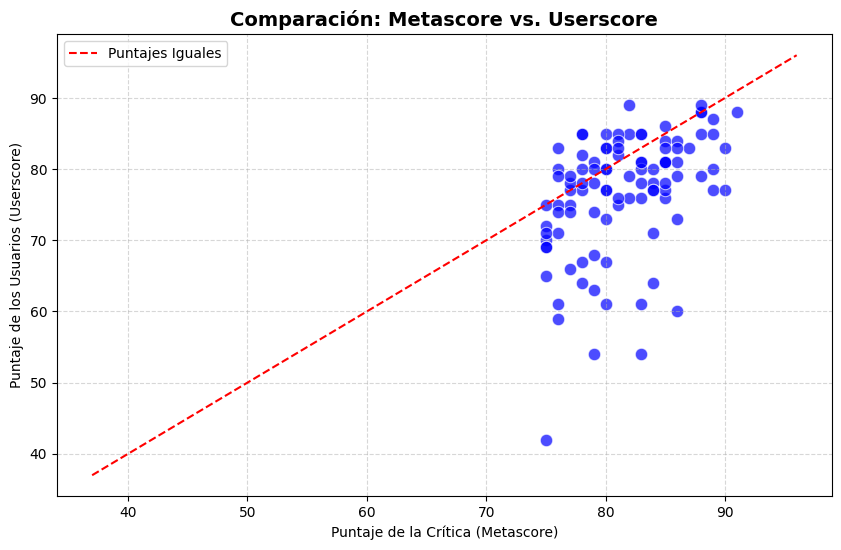

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='metascore', y='userscore', color='blue', alpha=0.7, s=80)

minimo = min(df['metascore'].min(), df['userscore'].min()) - 5
maximo = max(df['metascore'].max(), df['userscore'].max()) + 5
plt.plot([minimo, maximo], [minimo, maximo], color='red', linestyle='--', label='Puntajes Iguales')

plt.title('Comparación: Metascore vs. Userscore', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de la Crítica (Metascore)')
plt.ylabel('Puntaje de los Usuarios (Userscore)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Al evaluar el gráfico de dispersión resultante, se evidencia una clara tendencia central. En su gran mayoría, los puntajes otorgados por Metacritic no distan significativamente de las valoraciones de los usuarios. Esta alineación sugiere que no existe una polarización extrema en la muestra analizada; es decir, los títulos bien valorados por la prensa tienden a replicar ese mismo éxito entre la comunidad de jugadores.

#### **Analisis de relación entre genero y puntaje de criticos y jugadores**

Con el objetivo de identificar si el género de un videojuego influye significativamente en la percepción de la crítica especializada, se generó un diagrama de cajas cruzando la variable numérica metascore con las categorías individuales extraídas de la columna genres.

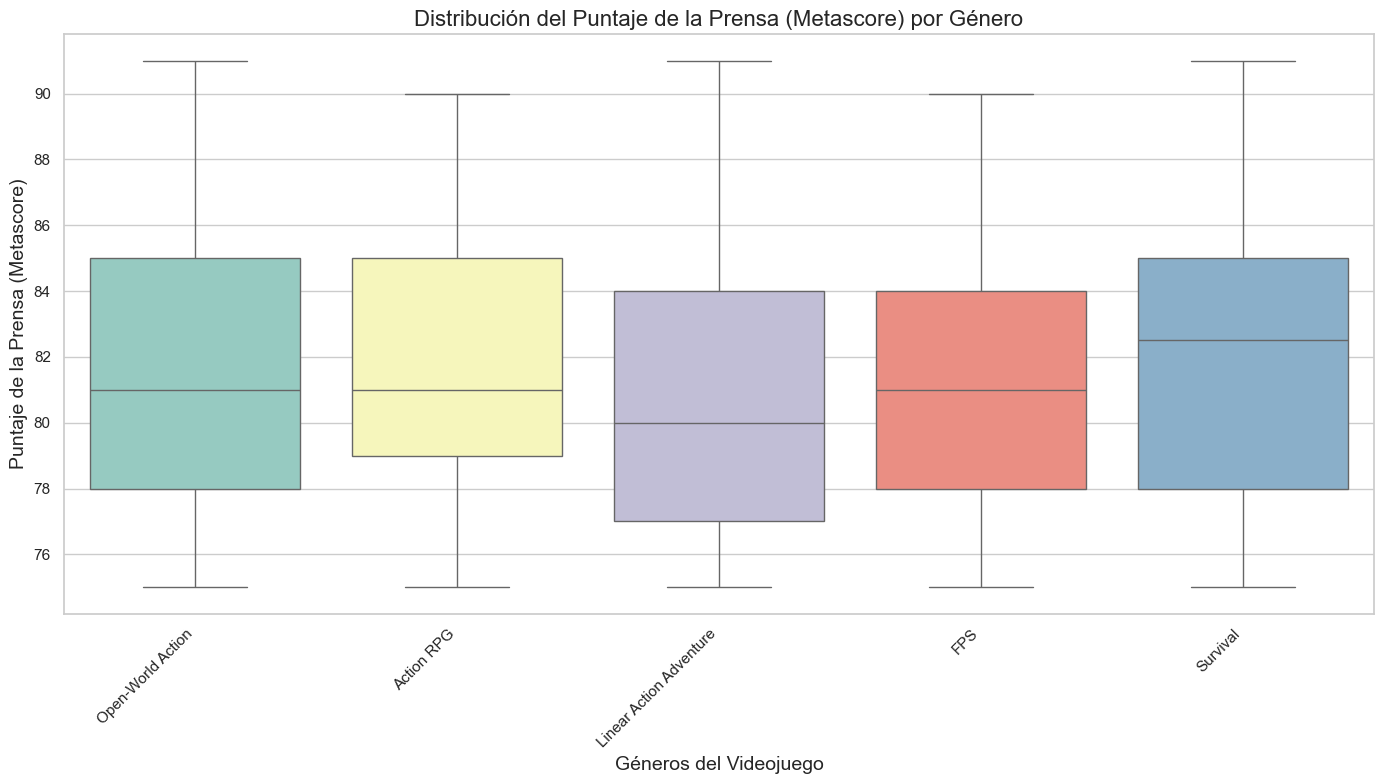

In [ ]:
df_genres = df.copy()
df_genres["genres"] = df_genres["genres"].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)
df_genres = df_genres.explode("genres")

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df_genres, x="genres", y="metascore", hue="genres", palette="Set3", legend=False)

plt.title("Distribución del Puntaje de los críticos (Metascore) por Género", fontsize=16)
plt.xlabel("Géneros del Videojuego", fontsize=14)
plt.ylabel("Puntaje de los críticos (Metascore)", fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Observaciones del Boxplot:**
* **Concentración de Puntajes:** Las cajas que representan las calificaciones de los críticos muestran una gran concentración de notas. La desviación estándar en todos los géneros se sitúa en torno a los 4 puntos, lo que indica que la crítica profesional es bastante homogénea, consistente y poco polarizada a la hora de evaluar estos títulos.
* **Favoritos de la Crítica:** El género "Survival" es el mejor puntuando, con una mediana de puntuación más alta (82.5 puntos). Le siguen "Action RPG", "FPS"* y "Open-World Action", todos empatados con una mediana de 81.0.
* **Puntuaciones conservadoras:** El género *"Linear Action Adventure"* es el que presenta la mediana más baja del conjunto (80.0). No obstante, es importante destacar que incluso el límite inferior de su caja sigue manteniéndose en un rango de calidad "Generalmente favorable".

**Impacto para el Sistema de Recomendación:**
Desde la perspectiva del negocio, esta visualización es fundamental para evaluar la métrica de calidad y relevancia de nuestro modelo. Dado que los críticos califican con puntajes altos y muy similares a todos los géneros de nuestra muestra, el atributo metascore por sí solo podría no ser un discriminador lo suficientemente fuerte para que el algoritmo encuentre similitudes finas. Sin embargo, esta distribución nos garantiza que cualquier juego que recomendemos de nuestra base, va a ser lo suficientemente bueno.

#### **Analisis de relacion entre genero y puntaje de criticos y jugadores**

Con el objetivo de identificar si el género de un videojuego influye significativamente en la percepción de los jugadores, se generó un diagrama de cajas cruzando la variable numérica userscore con las categorías individuales extraídas de la columna genres.

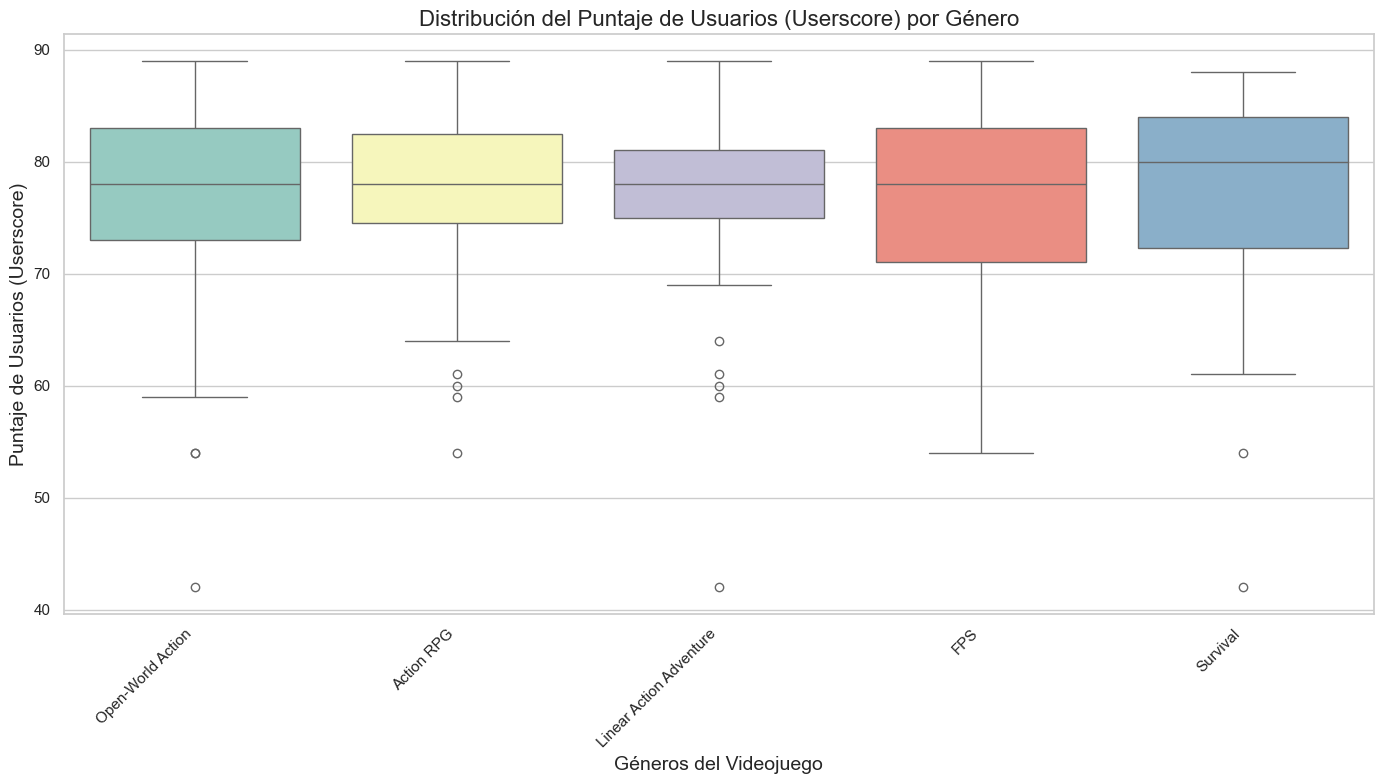

In [ ]:
df_genres = df.copy()
df_genres["genres"] = df_genres["genres"].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)
df_genres = df_genres.explode("genres")


plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")


sns.boxplot(data=df_genres, x="genres", y="userscore", hue="genres", palette="Set3", legend=False)


plt.title("Distribución del Puntaje de Usuarios (Userscore) por Género", fontsize=16)
plt.xlabel("Géneros del Videojuego", fontsize=14)
plt.ylabel("Puntaje de Usuarios (Userscore)", fontsize=14)


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Observaciones del Boxplot:**
* **Tendencia Central:** La comunidad de jugadores evalúa de manera bastante pareja a la mayoría de los géneros, ubicando las medianas de satisfacción en torno a los 78 puntos. Sin embargo, el género **"Survival"** se destaca levemente con la mediana más alta con 80 puntos.
* **Dispersión y Riesgo:** Aunque "Survival" tiene la mejor puntuación central, su caja y bigotes son los más extendidos, presentando la mayor dispersión de sus valores. Esto indica que es un género con mayor variabilidad en las valoraciones.
* **Consistencia:** Por el contrario, los géneros como **"Action RPG"** muestran cajas más compactas (menor dispersión, $\approx 7.50$), lo que demuestra un nivel de satisfacción mucho más predecible y estable entre los usuarios.

**Impacto para el Sistema de Recomendación:**
Desde la perspectiva del negocio, este gráfico nos indica el "riesgo" asociado a recomendar ciertos tipos de juegos. Un Action RPG funciona como una "apuesta segura" para el algoritmo, ya que rara vez decepciona gravemente a los usuarios. Por el contrario, recomendar un juego de Survival tiene un riesgo mayor debido a su alta polarización, por lo que el algoritmo debería cruzar este género con otros atributos para asegurar que el título sugerido sea realmente relevante.

**Conclusión Comparativa: Críticos vs Comunidad según Género**

Al contrastar las distribuciones de puntajes otorgados por los críticos frente a los de la comunidad de jugadores, se observan diferencias relevantes para el modelado de nuestro sistema de recomendación:

**Consenso vs Variabilidad:**
La diferencia más notable radica en la dispersión de los datos. Las valoraciones de la crítica presentan una distribución más homogénea, lo que parce mostrar una mayor consistencia en la evaluación de los distintos géneros. 

Por el contrario, las valoraciones de los usuarios muestran una variabilidad considerablemente mayor. Esto sugiere que la experiencia subjetiva del jugador es más heterogénea y menos uniforme.

#### 2.3.3 Analisis de relacion entre puntaje y cantidad de evaluadores

Para ver que tan significativa es cada nota de cada juego decidimos tomar una muestra de 20 juegos de manera aleatoria, y comparar la nota que estos poseen tanto de criticos como de jugadores y la cantidad de personas involucradas en cada puntuacion, para ver cual puede llegar a ser mas representativa, si la de los criticos o la de los jugadores

En esta sección, se presenta un análisis visual que integra cuatro variables críticas para cada videojuego en la muestra aleatoria de 20 títulos:

* **Largo de Barra:** Representa el peso o respaldo estadístico (la cantidad de personas involucradas en la calificación).
* **Nota Adjunta:** Representa la calidad percibida.

Este análisis se desglosa desde las dos perspectivas clave del dataset: la Crítica Especializada y la Comunidad.

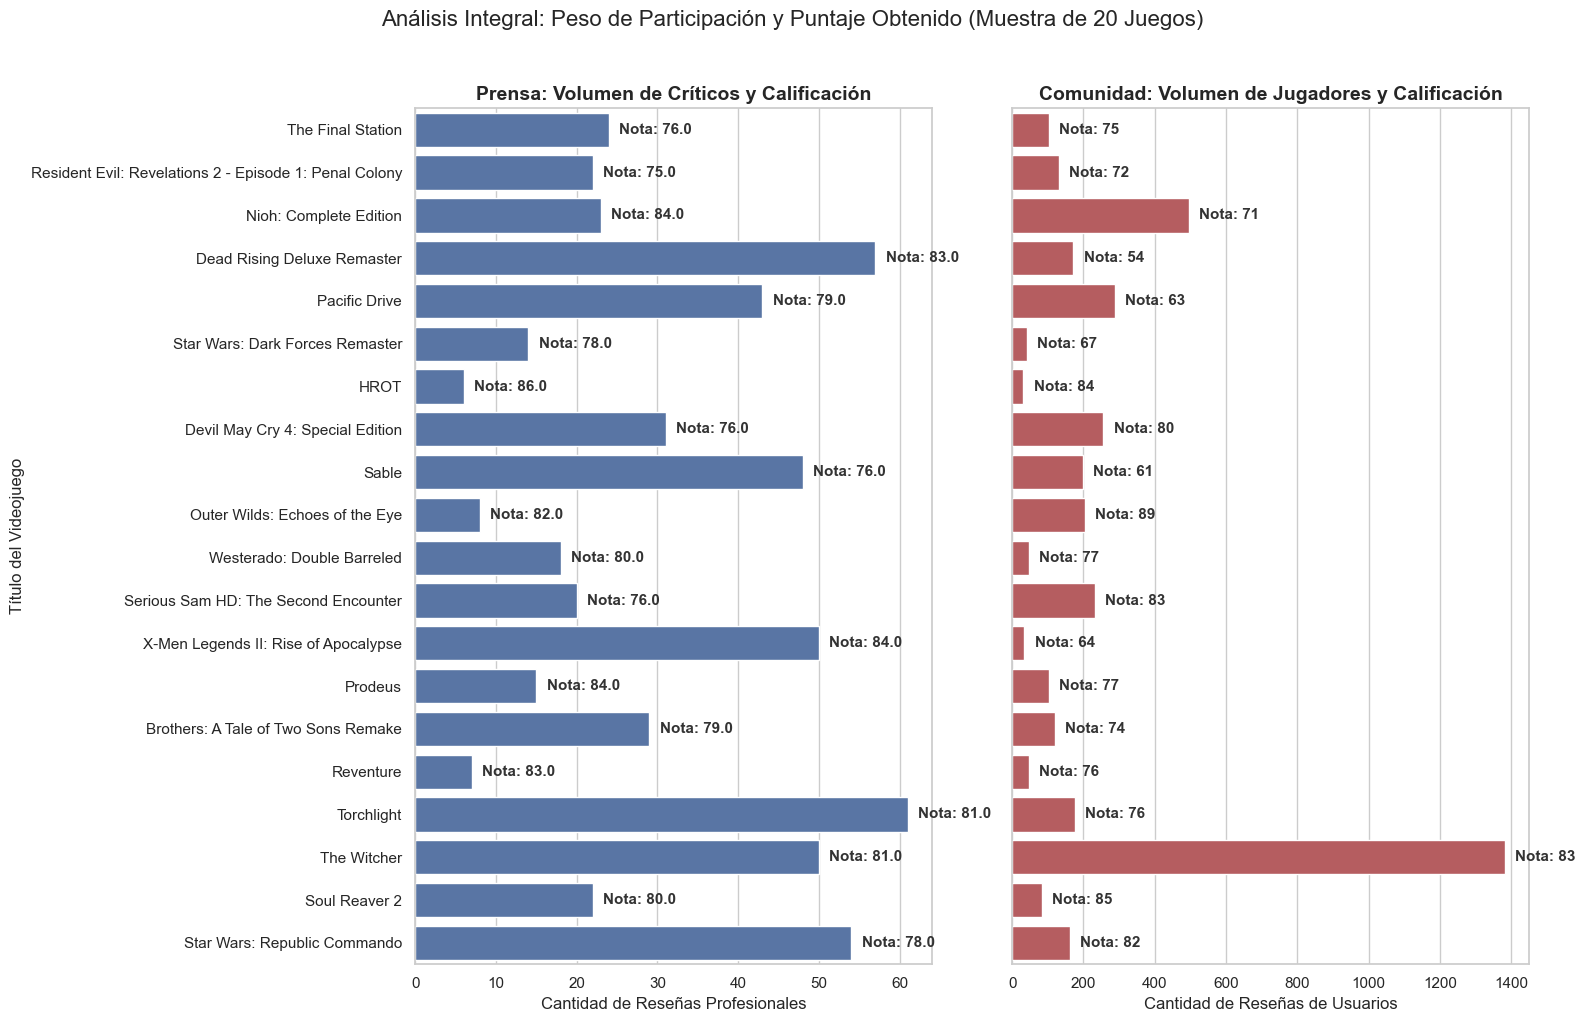

In [ ]:
df_random = df.sample(n=20, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)
sns.set_theme(style="whitegrid")


sns.barplot(data=df_random, x="metascore_count", y="title", ax=axes[0], color="#4C72B0")
axes[0].set_title("Prensa: Volumen de Críticos y Calificación", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Cantidad de Reseñas Profesionales", fontsize=12)
axes[0].set_ylabel("Título del Videojuego", fontsize=12)


for i, (count, score) in enumerate(zip(df_random['metascore_count'], df_random['metascore'])):
    margen = axes[0].get_xlim()[1] * 0.02
    axes[0].text(count + margen, i, f'Nota: {score}', va='center', fontsize=11, fontweight='bold', color='#333333')


sns.barplot(data=df_random, x="userscore_count", y="title", ax=axes[1], color="#C44E52")
axes[1].set_title("Comunidad: Volumen de Jugadores y Calificación", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Cantidad de Reseñas de Usuarios", fontsize=12)
axes[1].set_ylabel("") 


for i, (count, score) in enumerate(zip(df_random['userscore_count'], df_random['userscore'])):
    margen = axes[1].get_xlim()[1] * 0.02
    axes[1].text(count + margen, i, f'Nota: {score}', va='center', fontsize=11, fontweight='bold', color='#333333')


fig.suptitle("Análisis Integral: Peso de Participación y Puntaje Obtenido (Muestra de 20 Juegos)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Observaciones Estructurales Persistentes:**
* **Disparidad de Escalas (El "Peso"):** Al contrastar ambos gráficos, se evidencia que la participación opera en magnitudes distintas. Los críticos evalúan en decenas, mientras que la comunidad interactúa en la escala de los miles.
* **Distribución de la Calidad :**
* * **Prensa (Metascore):** Las calificaciones tienden a concentrarse en la franja superior (generalmente >75), demostrando una crítica pareja.
  * **Comunidad (Userscore):** Presenta una varianza mucho mayor. Se observan títulos masivos con calificaciones divisivas, así como juegos de nicho con puntuaciones de excelencia. La opinión comunitaria es significativamente más polarizada.

* **Desacople entre Cobertura y Popularidad:** Los juegos que acaparan la mayor atención mediática no son obligatoriamente los que generan mayor tracción en la comunidad, y viceversa. El interés periodístico y el éxito orgánico entre los jugadores no siempre están directamente correlacionados.

**Conclusión:**
Esta exploración confirma que la percepción de valor de un videojuego es un fenómeno multidimensional. Para cumplir con los objetivos del comitente, el sistema recomendador no puede basarse en una lógica unidimensional. Hacerlo introduciría un sesgo riesgoso al sugerir títulos con un respaldo estadístico insuficiente.

El algoritmo a desarrollar deberá implementar una métrica de **"Relevancia Ponderada"** que integre tanto la Calidad (Score) como la Confianza (Count). Asimismo, las divergencias encontradas en los gráficos proporcionan la base matemática para satisfacer las métricas de serendipia y diversidad, permitiendo que el modelo proponga un carrusel equilibrado entre juegos de altísima popularidad y joyas ocultas que sorprendan al usuario.

#### 2.3.3 Analisis de relacion entre metascore y userscore

Para conocer la relación entre la cantidad de géneros presentes por plataforma, procederemos a utilizar un mapa de calor. Dado que las variables plataformas y generos contienen múltiples valores combinados por celda, fue necesario aplicar una doble expansión en los datos para obtener una tabla de contingencia precisa. Esta visualización nos permite identificar visualmente las intersecciones con mayor volumen de juegos a través de la intensidad del color.

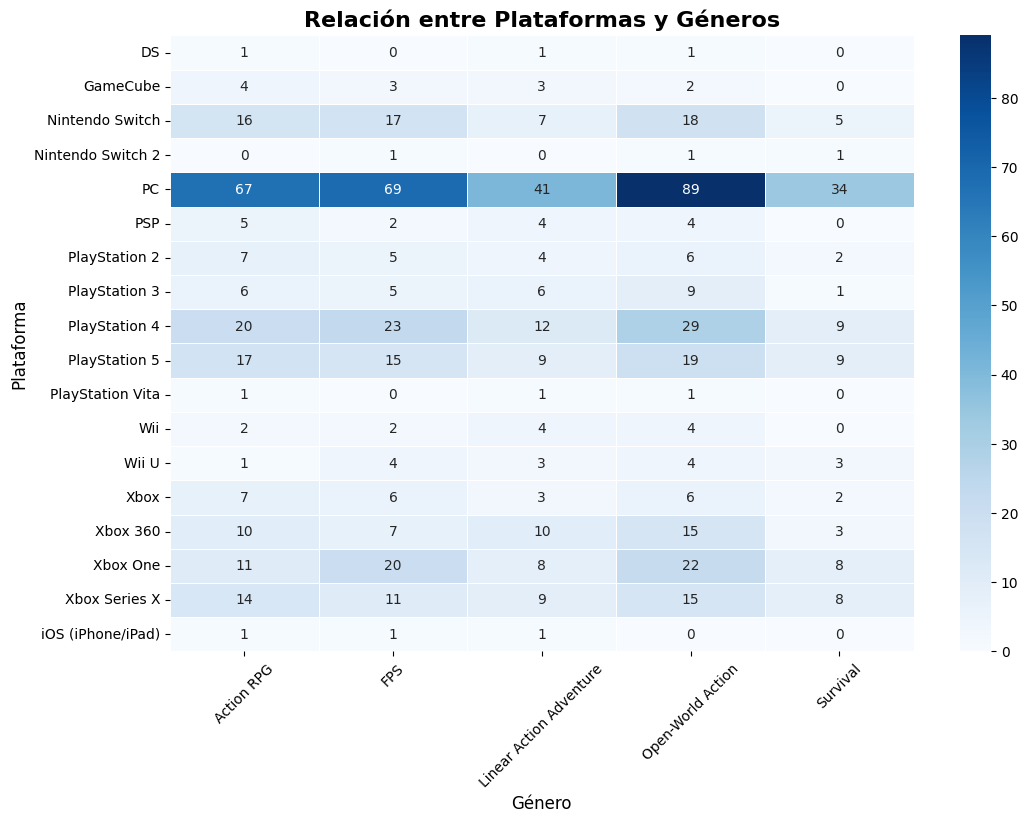

In [ ]:
df_gen = df.assign(genero=df['genres'].str.split(',')).explode('genero')
df_gen['genero'] = df_gen['genero'].str.strip()

df_plat_gen = df_gen.assign(plataforma=df_gen['platforms'].str.split(',')).explode('plataforma')
df_plat_gen['plataforma'] = df_plat_gen['plataforma'].str.strip()

tabla_cruzada = pd.crosstab(df_plat_gen['plataforma'], df_plat_gen['genero'])


plt.figure(figsize=(12, 8)) # Hacemos el lienzo un poco más grande

sns.heatmap(tabla_cruzada, annot=True, cmap='Blues', fmt='d', linewidths=.5)

plt.title('Relación entre Plataformas y Géneros', fontsize=16, fontweight='bold')
plt.ylabel('Plataforma', fontsize=12)
plt.xlabel('Género', fontsize=12)

plt.xticks(rotation=45) 

plt.show()

* **Dominancia de PC:** El mapa de calor revela una fuerte asimetría en la distribución. Ya que todos los juegos del dataset están disponibles en **"PC"**. 

* **Distribución en consolas modernas:** Consolas como la *Nintendo Switch*, *PlayStation 4* y *PlayStation 5* muestran una distribución secundaria sólida, acompañando las tendencias generales. Sus catálogos en esta muestra se apoyan fuertemente en los géneros *FPS* y *Open-World Action*, mientras que el género *Survival* tiene una adopción considerablemente menor en estas plataformas.

* **Plataformas minoritarias:** Se observa una gran cantidad de plataformas clásicas o portátiles que registran frecuencias marginales.

#### Conclusión
El análisis muestra que los géneros están distribuidos de forma bastante uniforme dentro del dataset, sin diferencias marcadas que permitan utilizarlos como un factor discriminante fuerte. Entonces, no se consideran una variable prioritaria en el modelo, ya que aportarían poca información relevante y no se usará en la recomendación.

## 2.4: Verificación de la calidad de los datos

### Instancia 2.4.1: Análisis de valores nulos
Recapitulando, teníamos 22 valores nulos en el atributo "rating". Los nulos pueden tener varias explicaciones lógicas. Pueden ser porque:
<br>
<br>

* El juego es apto para todo público y no se especificó porque no tiene restricciones.
* El juego no fue clasificado por ESRB.
* El juego si tiene clasificación pero el dataset no la registró porque la clasificación se realizó hace poco y el juego se cargó hace mucho en el dataset.



## Fase 3 - Preparación de los datos

Se procede a disminuir las columnas del data frame, asi poseemos un data frame util (dfu) con el cual trabajar con comodidad. Las columnas que dejaremos seran las siguientes: id, title, genres, description, platforms, metascore, userscore

**Transformación de variables categóricas: One-Hot Encoding**

El atributo "genres" presenta una estructura multivaluada, ya que cada juego puede pertenecer a múltiples géneros al mismo tiempo. Para el modelo, necesitamos una variable numérica.

Para resolver este problema, se aplicó la técnica de codificación **One-Hot Encoding**, la cual transforma cada categoría posible en una variable binaria independiente. Entonces, se genera una nueva columna por cada género, donde el valor es 1 si el juego pertenece a dicho género y 0 en caso contrario.

In [6]:
dfu = df[['id', 'title', 'genres', 'description', 'platforms', 'metascore', 'userscore']]

dfu['genres_limpios'] = dfu['genres'].apply(lambda x: '|'.join([g.strip() for g in x.split(',')]))

columnas_generos = dfu['genres_limpios'].str.get_dummies(sep='|')

genre_mapping = {
    'Open-World Action': 'open_world_action',
    'FPS': 'fps',
    'Survival': 'survival',
    'Action RPG': 'action_rpg',
    'Linear Action Adventure': 'linear_action_adventure'
}

columnas_generos = columnas_generos.rename(columns=genre_mapping)

dfu = pd.concat([dfu, columnas_generos], axis=1)

dfu = dfu.drop(columns=['genres', 'genres_limpios'])

dfu.head()

C:\Users\juan-\AppData\Local\Temp\ipykernel_1432\3862077765.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfu['genres_limpios'] = dfu['genres'].apply(lambda x: '|'.join([g.strip() for g in x.split(',')]))


,id,title,description,platforms,metascore,userscore,action_rpg,fps,linear_action_adventure,open_world_action,survival
0,1300540639,Outer Wilds: Echoes of the Eye,A strange satellite photo that can’t be explai...,PC,82.0,89,1,0,1,1,0
1,1300473095,Yakuza Kiwami 2,Kazuma Kiryu thought his Tojo Clan days were b...,"PlayStation 4,PC,Xbox One,Nintendo Switch 2",85.0,84,0,1,0,1,1
2,1300536274,Lost Judgment,"SEIZE THE TRUTH - December 2021, Tokyo distric...","PlayStation 5,Xbox Series X,PlayStation 4,PC",82.0,85,0,1,0,1,1
3,1300069209,Darksiders II,"Awakened by the End of Days, Death, the most f...","Xbox 360,PlayStation 3,PC,Wii U",83.0,81,0,1,1,1,0
4,1300491974,Reventure,The one and only non-linear adventure with 100...,"PC,Nintendo Switch",83.0,76,0,1,1,1,0


Guardar en "../database/juegos.csv"

In [ ]:
dfu.to_csv("../database/juegos.csv", index=False)

## Fase 4 - Modelado

### 4.1 Representación del Perfil del Usuario

Para el sistema recomendador adoptamos un enfoque **basado en contenido**, donde tanto los usuarios como los ítems son representados en un mismo espacio de características.

Siendo $k$ el número de géneros considerados en el sistema, cada usuario $u$ es representado mediante un vector de preferencias:

$$
u = (u_1, u_2, ..., u_k)
$$

donde cada componente $u_i$ toma valores en el rango $[0,10]$ y representa el grado de preferencia del usuario por el género $i$.

En nuestro caso, el espacio de características está compuesto por los siguientes géneros:

- Open-World Action  
- FPS  
- Survival  
- Action RPG  
- Linear Action Adventure  

De esta forma, cada usuario registra su perfil de preferencias al momento de crear su cuenta, lo que permite **mitigar el problema de cold-start** inicial.

### 4.2 Representación de los Ítems

Cada ítem se representa en el mismo espacio de características mediante un vector binario:

$$
x = (x_1, x_2, ..., x_k)
$$

donde:

- $x_i = 1$ si el ítem pertenece al género $i$
- $x_i = 0$ en caso contrario

Esta representación permite que usuarios e ítems existan en un **mismo espacio vectorial**, facilitando posteriormente el cálculo de afinidad entre ambos.

En lugar de depender únicamente de una matriz usuario-ítem altamente dispersa, el sistema utiliza esta representación basada en características para modelar las relaciones entre usuarios y videojuegos. Esto permite realizar operaciones simples sobre vectores de dimensión reducida para estimar similitud o preferencia.

La información de las características de los ítems se obtiene a partir del dataset de videojuegos procesado durante la etapa de preparación de datos.

### 4.3 Modelado de las Interacciones y Feedback Explícito

El sistema incorpora **feedback explícito**, permitiendo que los usuarios asignen un ranking discreto a los ítems con los que interactúan.

El ranking posible se define como:

$$
r \in \{1,2,3,4,5\}
$$

Cada interacción se registra como una tupla:

$$
(userId, itemId, ranking)
$$

Estas interacciones se almacenan persistentemente en el sistema y permiten mantener un historial del comportamiento del usuario.

Este mecanismo constituye la base para el aprendizaje incremental del perfil del usuario, ya que cada nueva interacción se utiliza para ajustar las preferencias registradas previamente.


### 4.4 Actualización Incremental del Perfil del Usuario

Para incorporar aprendizaje dinámico en el sistema, el perfil del usuario se actualiza después de cada interacción utilizando un esquema de **relevance feedback lineal**.

La actualización del perfil se define como:

$$
u_{new} = u_{old} + \alpha \cdot f(r) \cdot x
$$

donde:

- $\alpha$ es el peso de la transformación
- $f(r)$ es una función que transforma el ranking en un peso numérico
- $x$ es el vector de características del ítem evaluado

Los valores que utilizaremos son los siguientes

$$
\alpha = 0.5
$$

Cabe aclarar que se podría usar alpha como "factor de aprendizaje" y hacerlo variar de alguna manera, pero por simplicidad, mantendremos esto constante.

f(r) será la siguiente transformación del ranking:

- $f(1) = -0.25$
- $f(2) = -0.10$
- $f(3) = 0$
- $f(4) = 0.20$
- $f(5) = 0.10$

La actualización por cada género $i$ se define como:

$$
u_i = clamp(u_i + \alpha \cdot f(r) \cdot x_i)
$$

donde:

- $x_i \in \{0,1\}$ indica si el ítem pertenece al género $i$
- `clamp()` limita el valor al rango $[0,10]$

En código esto se ve así (`config.py`, `users_logic.py`):

In [ ]:
PREFERENCE_MIN_VALUE = 0.0
PREFERENCE_MAX_VALUE = 10.0
PREFERENCE_UPDATE_ALPHA = 0.5

RANKING_WEIGHT_MAP = {
    1: -0.25,
    2: -0.10,
    3: 0.0,
    4: 0.20,
    5: 0.10,
}

In [ ]:
# Limita el valor de una preferencia al rango permitido
def clamp_preference(value: float) -> float:
    return max(config.PREFERENCE_MIN_VALUE, min(config.PREFERENCE_MAX_VALUE, value))

def get_new_user_preference_value (current_value: float, game_value: float, ranking: int) -> float:
    ranking_weight = config.RANKING_WEIGHT_MAP.get(ranking, 0.0)
    # u_i = clamp(u_i + alpha * f(r) * x_i)
    return clamp_preference(current_value + config.PREFERENCE_UPDATE_ALPHA * ranking_weight * game_value)

# Actualiza las preferencias de un usuario a partir de un juego y un ranking dado por el usuario
def update_user_preferences_from_game(user_id: int, game_row, ranking: int) -> None:
    df = read_users_df()
    user_index = df.index[df[config.USER_ID_COLUMN] == user_id]

    if len(user_index) == 0:
        raise UserNotFoundException(user_id)

    idx = user_index[0]
    ranking_weight = config.RANKING_WEIGHT_MAP.get(ranking, 0.0)

    for game_column, user_column in config.GAME_TO_USER_ATTRIBUTE_MAP.items():
        game_value = float(game_row.get(game_column, 0))
        current_value = float(df.at[idx, user_column])
        new_value = get_new_user_preference_value(current_value, game_value, ranking)
        df.at[idx, user_column] = new_value

    save_users_df(df)

_Código de ejemplo, no ejecutará en Jupyter_

### 4.5 Sistema Recomendador

#### 4.5.1 Selección de la técnica

Para la construcción del sistema recomendador se evaluan las siguientes estrategias:

- **Filtrado colaborativo**: recomienda items a partir de similitudes entre usuarios o entre items según interacciones históricas.
- **Filtrado basado en contenido**: recomienda items en función de la similitud entre las características del item y el perfil de preferencias del usuario.

Se propone un **enfoque híbrido**, que combina ambas estrategias.

La elección de este enfoque se fundamenta en que el sistema puede obtener información de 2 fuentes:

Por un lado, la representación explícita del perfil de cada usuario mediante preferencias sobre distintos tipos de videojuegos, así como una representación de los ítems basada en esos mismos atributos. Esto permite aplicar técnicas de filtrado basado en contenido.

A su vez, el sistema registra las interacciones usuario–item a través de las valoraciones (rankings) almacenadas. Estas interacciones constituyen la base para la construcción de un modelo de filtrado colaborativo, que permite capturar patrones de comportamiento colectivo y relaciones entre usuarios e ítems.

En la etapa actual del proyecto, el componente basado en contenido tiene un rol predominante, ya que permite mitigar el problema de cold-start y generar recomendaciones desde el inicio. Sin embargo, a medida que el sistema crece y aumenta el volumen de interacciones registradas, el componente colaborativo adquiere mayor relevancia.

De esta manera, el sistema se concibe desde su diseño como un recomendador híbrido, donde las recomendaciones resultan de la combinación de información basada en contenido y en comportamiento colectivo, permitiendo aprovechar las ventajas de ambos enfoques.

#### 4.5.2 Combinación de puntajes

Una vez definidos los dos componentes del sistema recomendador, la generación de la recomendación final puede expresarse como una combinación de ambos puntajes: el puntaje basado en contenido y el puntaje basado en filtrado colaborativo.

Sea:

- $score_{contenido}(u, i)$ el puntaje obtenido a partir de la afinidad entre el vector de preferencias del usuario $u$ y el vector de características del videojuego $i$.
- $score_{colaborativo}(u, i)$ el puntaje estimado a partir de las valoraciones registradas por otros usuarios sobre el videojuego $i$.

Entonces, el puntaje final de recomendación se define como:

$$
score_{final}(u, i) = \alpha \cdot score_{contenido}(u, i) + (1-\alpha) \cdot score_{colaborativo}(u, i)
$$

donde $\alpha \in [0,1]$ es un parámetro de ponderación que regula la contribución relativa de cada componente.

En este esquema:

- si $\alpha$ toma un valor cercano a 1, predomina el componente basado en contenido;
- si $\alpha$ toma un valor cercano a 0, predomina el componente colaborativo.

Dado que en la etapa actual del proyecto el sistema dispone de una representación explícita del perfil del usuario y de un volumen todavía reducido de interacciones históricas, resulta conveniente asignar un mayor peso al componente basado en contenido. Sin embargo, a medida que aumente la cantidad de valoraciones registradas, este parámetro podrá ajustarse para incrementar progresivamente la influencia del componente colaborativo.

De esta forma, la arquitectura híbrida propuesta permite mantener la capacidad de recomendación en situaciones de cold-start, al mismo tiempo que incorpora información colectiva cuando esta se vuelve suficientemente representativa.

#### 4.5.3 Componente colaborativo

El componente colaborativo incorpora información proveniente de las valoraciones realizadas por otros usuarios. Este componente busca aprovechar patrones de comportamiento colectivo para estimar si un videojuego puede resultar adecuado para un usuario determinado.

La idea es la siguiente: si usuarios con perfiles similares valoraron positivamente un videojuego, entonces ese videojuego debería incrementar su puntaje de recomendación. En cambio, si usuarios similares lo valoraron negativamente, su puntaje debería disminuir.

Para implementar este componente se definieron tres pasos: transformación del ranking, cálculo de similitud entre usuarios y agregación ponderada de las valoraciones.

##### 4.5.3.1 Transformación del ranking

El sistema almacena valoraciones explícitas en una escala de 1 a 5. Para el cálculo del puntaje colaborativo queremos diferenciar entre valoraciones positivas, neutras y negativas.

Cada ranking se transforma a una señal centrada en cero mediante una función \(g(r)\). De esta manera, una valoración alta aporta positivamente al score, una valoración intermedia no altera el resultado, y una valoración baja lo penaliza.

La transformación utilizada es la siguiente:

$$
g(r)=
\begin{cases}
-1 & \text{si } r=1 \\
-0.5 & \text{si } r=2 \\
0 & \text{si } r=3 \\
0.5 & \text{si } r=4 \\
1 & \text{si } r=5
\end{cases}
$$

Esto permite representar de forma explícita que una mala valoración no debe equivaler a ausencia de información, sino a una señal negativa.

In [ ]:
def transform_ranking(ranking: int) -> float:
    ranking_map = {
        1: -1.0,
        2: -0.5,
        3: 0.0,
        4: 0.5,
        5: 1.0,
    }
    return ranking_map.get(int(ranking), 0.0)

##### 4.5.3.2 Similitud entre usuarios

Para ponderar adecuadamente las valoraciones de otros usuarios, es necesario estimar qué tan parecido es cada usuario respecto del usuario objetivo. En este caso, la similitud entre usuarios se va a calcular a partir de sus vectores de preferencias explícitas.

Dado que cada usuario se representa mediante un vector numérico en el mismo espacio de características, una forma adecuada de medir cercanía es mediante la **similitud del coseno**. Esta métrica compara la orientación entre dos vectores y toma valores entre 0 y 1 cuando todas las componentes son no negativas.

Sean \(u\) y \(v\) dos usuarios representados por sus vectores de preferencias, entonces su similitud se define como:

$$
sim(u,v)=\frac{u \cdot v}{\|u\|\|v\|}
$$

Cuanto más próximo a 1 sea este valor, mayor será la similitud entre ambos perfiles.

In [ ]:
import math

FEATURES = [
    "open_world_action_preference",
    "fps_preference",
    "survival_preference",
    "action_rpg_preference",
    "linear_action_adventure_preference",
]

def compute_user_similarity(user_row_a, user_row_b) -> float:
    a = [float(user_row_a.get(feature, 0.0)) for feature in FEATURES]
    b = [float(user_row_b.get(feature, 0.0)) for feature in FEATURES]

    dot_product = sum(x * y for x, y in zip(a, b))
    norm_a = math.sqrt(sum(x * x for x in a))
    norm_b = math.sqrt(sum(y * y for y in b))

    if norm_a == 0 or norm_b == 0: return 0.0

    return dot_product / (norm_a * norm_b)

##### 4.5.3.3 Cálculo del puntaje colaborativo

El puntaje colaborativo de un videojuego para un usuario dado puede calcularse agregando las valoraciones de otros usuarios que ya calificaron dicho videojuego.

Sea \(u\) el usuario objetivo, \(i\) el videojuego a evaluar, \(V_i\) el conjunto de usuarios que valoraron el videojuego \(i\), \(sim(u,v)\) la similitud entre el usuario objetivo \(u\) y otro usuario \(v\), y \(g(r_{v,i})\) la transformación de la valoración de \(v\) sobre el videojuego \(i\). Entonces:

$$
score_{colaborativo}(u,i)=
\frac{\sum_{v \in V_i} sim(u,v)\cdot g(r_{v,i})}
{\sum_{v \in V_i} |sim(u,v)|}
$$

Esta expresión puede interpretarse como un promedio ponderado de las valoraciones transformadas, donde las opiniones de usuarios más similares tienen mayor influencia.

De esta manera:

- si usuarios similares valoraron positivamente el videojuego, el puntaje colaborativo aumenta.
- si usuarios similares lo valoraron negativamente, el puntaje disminuye.
- si no existe información suficiente, el puntaje colaborativo se aproxima a cero.

#

## Fase 5 - Evaluación
BLA

## Fase 6 - Despliegue
BLA

## NOTAS PARA REVISAR

PARA VERIFICAR LA SERENDIPIA: Se considerarán recomendaciones esperables aquellas que coincidan con las sugerencias obtenidas mediante un modelo trivial de recomendación (por ejemplo, basado en popularidad o similitud directa con artículos consumidos previamente por ese usuario). Las recomendaciones que resulten relevantes para el usuario pero no pertenezcan a ese conjunto serán consideradas serendípicas.

PARA VERIFICAR LA RELEVANCIA: Un ítem es relevante si cumple en cierta medida con las preferencias del usuario (habría que ajustar como medimos si cumple o no)

PARA VERIFICAR LA NOVEDAD: Fijarse nomás si el ítem recomendado ya tiene rating por parte del usuario (si ya lo tiene, está mal, no cumple)

PARA VERIFICAR LA DIVERSIDAD: Mepa que hay métricas de diversidad hechas para esto, utilizaremos esta, más adelante vemos.

REVISAR SI USAMOS TODAS LAS LIBRERÍAS CARGADAS